In [145]:
import warnings
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.formula.api as smf

# Preprocessing
## Loading data

In [146]:
data_file = "VAL_THO_GF.xlsx"

cols = {
    'Datum': 'date',
    'Position': 'position',
    'Fachabteilung': 'dept',
    'Saal': 'room',
    'Notfallkategorie': 'priority',
    'procedureData_originductionmethod': 'anes_method',
    'procedureData_patientpositioning': 'procedure_type',

    'In Schleuse': 'arrival_airlock',
    'documented_anesthesiastarttimestamp': 'anes_start',
    'documented_anesthesiareleasetimestamp': 'anes_release',
    'Schnitt': 'incision',
    'Naht': 'suture',
    'Ende Anästhesie': 'wakeup',
    'documented_incisiontimestamp': 'incision_doc',
    'documented_suturetimestamp': 'suture_doc',
    'auxilaryData_incisionTimestamp': 'incision_aux',
    'auxilaryData_sutureTimestamp': 'suture_aux',
    'auxilaryData_anesthesiaEndTimestamp': 'wakeup_aux',
    'auxilaryData_expectedSutureTimestamp': 'suture_expected',
}

time_cols = ['arrival_airlock', 'anes_start', 'anes_release', 'incision', 'suture', 'wakeup', 'incision_doc',
             'suture_doc', 'incision_aux', 'suture_aux', 'wakeup_aux', 'suture_expected']

df = pd.read_excel("data/" + data_file, header=0, usecols=cols.keys(), dtype=str)
df = df.rename(columns=cols)

df['position'] = pd.to_numeric(df['position'], errors='coerce')

for col in time_cols:
    if col in df.columns:
        col_data = df[col]
        if col_data.str.contains(r'\d{4}-\d{2}-\d{2}').any():
            timestamps = pd.to_datetime(col_data, format='%Y-%m-%d %H:%M:%S', errors='coerce')
        elif col_data.str.contains(r'\d{2}\.\d{2}\.\d{4}').any():
            timestamps = pd.to_datetime(col_data, dayfirst=True, errors='coerce')
        df[col] = timestamps

## Calculating anesthesia time

In [147]:
anes_times = {
    # Base
    'AA': 20, 'RSI': 20, 'PIZA': 75, 'DLT': 30, 'Jet': 20,
    'BSWITN': 30, 'IVA': 20, 'SpA': 35, 'PDA': 35, 'CSE': 35,
    # Lines & Monitoring
    'Art': 10, 'ZVK': 10, 'TEE': 0, 'PICCO': 0, 'PAK': 0, 'Schleuse': 10,
    # Regional Blocks
    'PVB': 20, 'KDB': 20, 'CervB': 20, 'ISB': 20, 'SCB': 20, 'AxB': 20,
    'ObtB': 20, 'FemB': 15, 'PIB': 20, 'DIB': 20, 'SaphB': 10, 'FußB': 10,
    'TAPB': 15, 'FICB': 20, 'SonstB': 20, 'ivLido': 0, 'BDK': 5, 'Pe6': 5
}

aliases = {
    r'\bitn\b': 'AA',
    r'\bza\b': 'AA',
    r'\bpdk\b': 'PDA',
    r'\b(wach)?-?art(erie)?\b': 'Art',
    r'\bdk\b': 'BDK',
    r'\btap-?b?(lock)?\b': 'TAPB',
    r'\blido(cain)?(-?perf(usor)?)?\b': 'ivLido',
    r'\b(large\s*bore|shaldon)\b': 'Schleuse',
    r'\bpufi\b': 'Schleuse',
    r'\b(do-lu-?|dl-?)?tubus\b': 'DLT',
    r'\b(fuß|fuss)b(lock)?\b': 'FußB',
    r'\bpe-?6\b': 'Pe6'
}

unknown_methods = set()

def calc_expected_anes_time(anes_methods):
    if pd.isna(anes_methods):
        return pd.NA

    text = anes_methods.lower()
    total_time = 0
    found_procs = set()

    if re.search(r'p\s*i\s*z\s*a|p\s*\(\s*i\s*z\s*\)\s*a|p\s*i\s*\(\s*z\s*a\s*\)', text):
        total_time += 75
        found_procs.update(['PDA', 'AA', 'ZVK', 'Art']) # Prevent double-counting
    else:
        if re.search(r'i\s*z\s*w?a|i\s*z\s*\(\s*z\s*\)\s*a', text):
            if 'AA' not in found_procs: total_time += 20; found_procs.add('AA')
            if 'ZVK' not in found_procs: total_time += 10; found_procs.add('ZVK')
            if 'Art' not in found_procs: total_time += 10; found_procs.add('Art')

    for pattern, official_key in aliases.items():
        if re.search(pattern, text) and official_key not in found_procs:
            total_time += anes_times[official_key]
            found_procs.add(official_key)

    for key, time_val in anes_times.items():
        if re.search(rf'\b{key.lower()}\b', text) and key not in found_procs:
            total_time += time_val
            found_procs.add(key)

    if total_time == 0:
        return 0

    return total_time

df['anes_min'] = df['anes_method'].apply(calc_expected_anes_time)
df['anes_min'] = pd.to_numeric(df['anes_min'], errors='coerce')
print(unknown_methods)

set()


## Checking timestamps

In [148]:
warnings.filterwarnings('ignore')

events = ['suture', 'incision', 'wakeup']

pairs = [
    ('Core', '', 'Documented', '_doc'),
    ('Core', '', 'Auxiliary', '_aux'),
    ('Documented', '_doc', 'Auxiliary', '_aux')
]

print("=== MAGNITUDE OF DIFFERENCE & STATISTICAL BIAS ===\n")
for event in events:
    print(f"--- {event.upper()} TIMESTAMPS ---")

    for name1, suffix1, name2, suffix2 in pairs:
        col1 = f"{event}{suffix1}"
        col2 = f"{event}{suffix2}"

        if col1 not in df.columns or col2 not in df.columns:
            print(f"  {name1} vs {name2}: Column missing. Skipping.\n")
            continue

        mask = df[col1].notna() & df[col2].notna()

        if not mask.any():
            print(f"  {name1} vs {name2}: No overlapping data.\n")
            continue

        diff = (df.loc[mask, col1] - df.loc[mask, col2]).dt.total_seconds() / 60.0

        median_bias = diff.median()
        abs_median = diff.abs().median()
        extreme_95 = diff.abs().quantile(0.95)

        diff_no_zeros = diff[diff != 0]
        if len(diff_no_zeros) > 0:
            stat, p_value = stats.wilcoxon(diff_no_zeros)
        else:
            p_value = float('nan')

        print(f"  {name1} vs {name2} (n={mask.sum()}):")
        print(f"    Median Bias ({name1} - {name2}): {median_bias:>6.1f} min")
        print(f"    Typical Abs Error:             {abs_median:>6.1f} min")
        print(f"    95% of errors under:           {extreme_95:>6.1f} min")
        if np.isnan(p_value):
            print(f"    Wilcoxon P-Value:              N/A (Identical)")
        else:
            print(f"    Wilcoxon P-Value:              {p_value:>6.4f}")
    print("\n")

df['suture_final'] = df['suture_aux'].combine_first(df['suture_doc']).combine_first(df['suture'])
df['incision_final'] = df['incision_aux'].combine_first(df['incision_doc']).combine_first(df['incision'])
df['wakeup_final'] = df['wakeup_aux'].combine_first(df['wakeup'])

df['anes_prep_time'] = (df['anes_release'] - df['anes_start']).dt.total_seconds() / 60.0
df['wakeup_time'] = (df['wakeup_final'] - df['suture_final']).dt.total_seconds() / 60.0

=== MAGNITUDE OF DIFFERENCE & STATISTICAL BIAS ===

--- SUTURE TIMESTAMPS ---
  Core vs Documented (n=5577):
    Median Bias (Core - Documented):    2.0 min
    Typical Abs Error:                3.0 min
    95% of errors under:             14.0 min
    Wilcoxon P-Value:              0.0000
  Core vs Auxiliary (n=5578):
    Median Bias (Core - Auxiliary):    2.0 min
    Typical Abs Error:                3.0 min
    95% of errors under:             14.0 min
    Wilcoxon P-Value:              0.0000
  Documented vs Auxiliary (n=5644):
    Median Bias (Documented - Auxiliary):    0.0 min
    Typical Abs Error:                0.0 min
    95% of errors under:              0.0 min
    Wilcoxon P-Value:              0.0078


--- INCISION TIMESTAMPS ---
  Core vs Documented (n=5615):
    Median Bias (Core - Documented):    2.0 min
    Typical Abs Error:                2.0 min
    95% of errors under:             11.0 min
    Wilcoxon P-Value:              0.0000
  Core vs Auxiliary (n=5616):
  

## Clustering data

In [149]:
clusters = [['OP2-08', 'OP2-09', 'OP2-10'], ['OP2-11', 'OP2-12', 'OP2-13', 'OP2-14']]

all_rooms = df['room'].unique()
rooms_unused = set(all_rooms) - set(clusters[0]) - set(clusters[1])

print(f"Unused rooms: {rooms_unused}")

for c_idx, cluster in enumerate(clusters):
    df.loc[df['room'].isin(cluster), 'cluster'] = c_idx

in_clusters = df['cluster'].notna().sum()
out_clusters = df['cluster'].isna().sum()

print(f"Number of procedures in clusters: {in_clusters}\n"
      f"Number of procedures outside clusters: {out_clusters}")

print("\nBreakdown per cluster:")
print(df['cluster'].value_counts().sort_index())

Unused rooms: {'OP2-07', 'OP3-11', 'OP3-09', 'OP3-01', 'OP3-08', 'OP2-05', 'OP3-04', 'OP2-15', 'OP3-02', 'OP2-16', 'OP3-07', 'OP2-04', 'OP3-03', 'OP2-03', 'OP3-12', 'OP2-06', 'OP3-05', 'OP3-10', 'OP3-13', 'OP3-06'}
Number of procedures in clusters: 5849
Number of procedures outside clusters: 192

Breakdown per cluster:
cluster
0.0    2673
1.0    3176
Name: count, dtype: int64


# Turnover analysis
## Find turnovers

In [150]:
df_sorted = df.copy().sort_values(by=['room', 'suture_final'])

df_sorted['prev_suture'] = df_sorted.groupby('room')['suture_final'].shift(1)
df_sorted['prev_wakeup'] = df_sorted.groupby('room')['wakeup_final'].shift(1)

df_sorted['turnover_min'] = (df_sorted['incision_final'] - df_sorted['prev_suture']).dt.total_seconds() / 60.0
df_sorted['empty_min'] = (df_sorted['anes_start'] - df_sorted['prev_wakeup']).dt.total_seconds() / 60.0

mask_valid_turnovers = (
        df_sorted['turnover_min'].notna() &
        (df_sorted['turnover_min'] > 0) &
        (df_sorted['turnover_min'] <= 720)
)

df_turnovers = df_sorted[mask_valid_turnovers].copy()

## Calculating strain

In [151]:
def calculate_cluster_strain(row, df):
    suture_a = row['prev_suture']
    incision_a = row['incision_final']
    current_cluster = row['cluster']
    current_date = row['date']

    if pd.isna(suture_a) or pd.isna(current_cluster) or pd.isna(incision_a):
        return np.nan

    concurrent_mask = (
            (df['date'] == current_date) &
            (df['cluster'] == current_cluster) &
            (df['room'] != row['room']) &
            (suture_a < df['incision_final']) &
            (incision_a > df['prev_suture'])
    )

    return concurrent_mask.sum()


def calculate_cluster_strain_min(row, df):
    suture_a = row['prev_suture']
    incision_a = row['incision_final']
    current_cluster = row['cluster']
    current_date = row['date']

    if pd.isna(suture_a) or pd.isna(current_cluster) or pd.isna(incision_a):
        return np.nan

    concurrent_cases = df[
        (df['date'] == current_date) &
        (df['cluster'] == current_cluster) &
        (df['room'] != row['room']) &
        (suture_a < df['incision_final']) &
        (incision_a > df['prev_suture'])
        ].copy()

    if concurrent_cases.empty:
        return 0

    overlaps_timedelta = (
            np.minimum(incision_a, concurrent_cases['incision_final']) -
            np.maximum(suture_a, concurrent_cases['prev_suture'])
    )

    overlaps_min = overlaps_timedelta.dt.total_seconds() / 60.0

    return overlaps_min.sum()


df_turnovers['cluster_strain'] = df_turnovers.apply(
    lambda row: calculate_cluster_strain(row, df_turnovers),
    axis=1
)

df_turnovers['cluster_strain_min'] = df_turnovers.apply(
    lambda row: calculate_cluster_strain_min(row, df_turnovers),
    axis=1
)

df_turnovers['norm_cluster_strain'] = df_turnovers['cluster_strain_min'] / df_turnovers['turnover_min']

print("=== LOCALIZED CLUSTER STRAIN ===")
print("Strain Level | Number of Turnovers")
print("----------------------------------")
print(df_turnovers['cluster_strain'].value_counts().sort_index())


=== LOCALIZED CLUSTER STRAIN ===
Strain Level | Number of Turnovers
----------------------------------
cluster_strain
0.0    1551
1.0    1356
2.0     644
3.0      78
4.0       2
Name: count, dtype: int64


In [152]:
strain_percentages = df_turnovers['cluster_strain'].value_counts(normalize=True)

valid_strains = strain_percentages[strain_percentages >= 0.01].index.tolist()

df_clean = df_turnovers[df_turnovers['cluster_strain'].isin(valid_strains)].copy()

print("Original Strain Distribution:")
print((strain_percentages * 100).round(2).astype(str) + '%')

dropped_strains = sorted(set(strain_percentages.index) - set(valid_strains))
print(f"\nDynamic Action:")
print(f"- Kept Levels:    {sorted(valid_strains)}")
print(f"- Dropped Levels: {dropped_strains if dropped_strains else 'None'}")

total_kept_pct = (len(df_clean) / len(df_turnovers)) * 100
print(f"\nFinal Dataset: {len(df_clean)} turnovers retained ({total_kept_pct:.1f}% of total data)")

Original Strain Distribution:
cluster_strain
0.0    42.72%
1.0    37.35%
2.0    17.74%
3.0     2.15%
4.0     0.06%
Name: proportion, dtype: str

Dynamic Action:
- Kept Levels:    [0.0, 1.0, 2.0, 3.0]
- Dropped Levels: [4.0]

Final Dataset: 3629 turnovers retained (99.0% of total data)


## Baseline statistics

In [153]:
grouping_column = 'cluster'

mask_valid_turnover = (df_clean['turnover_min'] > 0)
df_valid_turnover = df_clean[mask_valid_turnover].copy()


def p95(x): return x.quantile(0.95)


def iqr(x): return x.quantile(0.75) - x.quantile(0.25)


print(">\n--- Baseline Behavior (Grouped by {grouping_column}) ---\n")
if grouping_column in df_valid_turnover.columns:
    turnover_summary_stats = df_valid_turnover.groupby(grouping_column)['turnover_min'].agg(
        Total_Surgeries='count',
        Median_Min='median',
        Mean_Min='mean',
        P95_Min=p95,
        IQR_Spread=iqr
    ).round(1)

    print(turnover_summary_stats.to_string())
else:
    print(f"Warning: Column '{grouping_column}' not found in dataframe.")

>
--- Baseline Behavior (Grouped by {grouping_column}) ---

         Total_Surgeries  Median_Min  Mean_Min  P95_Min  IQR_Spread
cluster                                                            
0.0                 1495       111.0     177.4    575.2        96.5
1.0                 2134       138.0     229.8    625.3       250.2


## Make a model

In [154]:
cols_needed = ['turnover_min', 'cluster_strain_min', 'anes_method', 'priority', 'dept', 'cluster', 'anes_min']
df_clean_turnover = df_clean[cols_needed].dropna()

x_cap = df_clean_turnover['cluster_strain_min'].quantile(0.98)
df_clean_turnover = df_clean_turnover[df_clean_turnover['cluster_strain_min'] <= x_cap]
y_cap = df_clean_turnover['turnover_min'].quantile(0.98)
df_clean_turnover = df_clean_turnover[df_clean_turnover['turnover_min'] <= y_cap]

turnover_d_model = smf.mixedlm(
    formula="turnover_min ~ cluster_strain_min + C(priority) + anes_min",
    data=df_clean_turnover,
    groups=df_clean_turnover["dept"]
)

turnover_d_result = turnover_d_model.fit()
print(turnover_d_result.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   turnover_min
No. Observations:    3063      Method:               REML        
No. Groups:          3         Scale:                19659.1981  
Min. group size:     323       Log-Likelihood:       -19469.8654 
Max. group size:     1751      Converged:            Yes         
Mean group size:     1021.0                                      
-----------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          214.287   63.290  3.386 0.001   90.241 338.332
C(priority)[T.N1]   33.218   65.183  0.510 0.610  -94.539 160.975
C(priority)[T.N2]    4.157   63.257  0.066 0.948 -119.825 128.138
C(priority)[T.N3]    5.835   63.038  0.093 0.926 -117.717 129.388
C(priority)[T.N4]  -71.996   63.287 -1.138 0.255 -196.036  52.044
C(priority)[T.N5]  -96.1

In [155]:
turnover_c_model = smf.mixedlm(
    formula="turnover_min ~ cluster_strain_min + C(priority) + anes_min",
    data=df_clean_turnover,
    groups=df_clean_turnover["cluster"]
)

turnover_c_result = turnover_c_model.fit()
print(turnover_c_result.summary())

              Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   turnover_min
No. Observations:    3063      Method:               REML        
No. Groups:          2         Scale:                19658.8662  
Min. group size:     1268      Log-Likelihood:       -19469.2479 
Max. group size:     1795      Converged:            Yes         
Mean group size:     1531.5                                      
-----------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------
Intercept          217.846   63.788  3.415 0.001   92.823 342.869
C(priority)[T.N1]   33.162   65.167  0.509 0.611  -94.564 160.887
C(priority)[T.N2]    4.460   63.239  0.071 0.944 -119.487 128.407
C(priority)[T.N3]    5.888   63.028  0.093 0.926 -117.645 129.421
C(priority)[T.N4]  -73.022   63.271 -1.154 0.248 -197.031  50.988
C(priority)[T.N5]  -96.3

# Anesthesia Prep Phase
## Calculating baseline metrics

In [156]:
grouping_column = 'cluster'

mask_valid_prep = (df_clean['anes_prep_time'] > 0) & (df_clean['anes_prep_time'] < 180)
df_valid_prep = df_clean[mask_valid_prep].copy()


def p95(x): return x.quantile(0.95)


def iqr(x): return x.quantile(0.75) - x.quantile(0.25)


print(f"--- Baseline Behavior (Grouped by {grouping_column}) ---")

if grouping_column in df_valid_prep.columns:
    prep_summary_stats = df_valid_prep.groupby(grouping_column)['anes_prep_time'].agg(
        Total_Surgeries='count',
        Median_Min='median',
        Mean_Min='mean',
        P95_Min=p95,
        IQR_Spread=iqr
    ).round(1)

    print(prep_summary_stats.to_string())
else:
    print(f"Warning: Column '{grouping_column}' not found in dataframe.")

--- Baseline Behavior (Grouped by cluster) ---
         Total_Surgeries  Median_Min  Mean_Min  P95_Min  IQR_Spread
cluster                                                            
0.0                 1379        21.0      25.2     64.1        25.0
1.0                 1995        23.0      28.4     65.0        28.0


## Make a model

In [157]:
cols_needed = ['anes_prep_time', 'cluster_strain_min', 'priority', 'cluster', 'dept', 'anes_min']

df_prep_clean = df_clean[cols_needed].dropna()

x_cap = df_prep_clean['cluster_strain_min'].quantile(0.98)
df_prep_clean = df_prep_clean[df_prep_clean['cluster_strain_min'] <= x_cap]
y_cap = df_prep_clean['anes_prep_time'].quantile(0.98)
df_prep_clean = df_prep_clean[df_prep_clean['anes_prep_time'] <= y_cap]

prep_model = smf.mixedlm(
    formula=f"anes_prep_time ~ cluster_strain_min + C(priority) + anes_min",
    data=df_prep_clean,
    groups=df_prep_clean['dept']
)

prep_result = prep_model.fit()
print("--- Impact of Cluster Strain on Prep Time ---")
print(prep_result.summary())

--- Impact of Cluster Strain on Prep Time ---
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: anes_prep_time
No. Observations: 3014    Method:             REML          
No. Groups:       3       Scale:              187.7933      
Min. group size:  307     Log-Likelihood:     -12168.3609   
Max. group size:  1735    Converged:          Yes           
Mean group size:  1004.7                                    
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          5.640    6.243  0.903 0.366 -6.596 17.877
C(priority)[T.N1]  7.811    6.364  1.227 0.220 -4.662 20.284
C(priority)[T.N2]  8.079    6.183  1.307 0.191 -4.040 20.198
C(priority)[T.N3]  5.286    6.162  0.858 0.391 -6.791 17.363
C(priority)[T.N4]  4.637    6.186  0.750 0.454 -7.488 16.762
C(priority)[T.N5]  9.004    6.144  1.466 0.143 -3.0

# Wake up
## Calculating baseline metrics

In [158]:
grouping_column = 'cluster'

mask_valid_wakeup = (df_clean['wakeup_time'] > 0) & (df_clean['wakeup_time'] < 180)
df_valid_wakeup = df_clean[mask_valid_wakeup].copy()


def p95(x): return x.quantile(0.95)


def iqr(x): return x.quantile(0.75) - x.quantile(0.25)


print(">\n--- Baseline Behavior (Grouped by {grouping_column}) ---\n")
if grouping_column in df_valid_wakeup.columns:
    wakeup_summary_stats = df_valid_wakeup.groupby(grouping_column)['wakeup_time'].agg(
        Total_Surgeries='count',
        Median_Min='median',
        Mean_Min='mean',
        P95_Min=p95,
        IQR_Spread=iqr
    ).round(1)

    print(wakeup_summary_stats.to_string())
else:
    print(f"Warning: Column '{grouping_column}' not found in dataframe.")

>
--- Baseline Behavior (Grouped by {grouping_column}) ---

         Total_Surgeries  Median_Min  Mean_Min  P95_Min  IQR_Spread
cluster                                                            
0.0                 1310        18.0      21.6     53.0        18.0
1.0                 1918        16.0      20.6     51.0        15.0


## Model

In [159]:
cols_needed = ['wakeup_time', 'cluster_strain_min', 'priority', 'cluster', 'dept']

df_wakeup_clean = df_clean[cols_needed].dropna()

x_cap = df_wakeup_clean['cluster_strain_min'].quantile(0.98)
df_wakeup_clean = df_wakeup_clean[df_wakeup_clean['cluster_strain_min'] <= x_cap]
y_cap = df_wakeup_clean['wakeup_time'].quantile(0.98)
df_wakeup_clean = df_wakeup_clean[df_wakeup_clean['wakeup_time'] <= y_cap]

wakeup_model = smf.mixedlm(
    formula=f"wakeup_time ~ cluster_strain_min + C(priority)",
    data=df_wakeup_clean,
    groups=df_wakeup_clean['dept']
)

wakeup_result = wakeup_model.fit()
print("--- Impact of Cluster Strain on Wakeup Time ---")
print(wakeup_result.summary())

--- Impact of Cluster Strain on Wakeup Time ---
            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  wakeup_time
No. Observations:    3212     Method:              REML       
No. Groups:          3        Scale:               294.1854   
Min. group size:     343      Log-Likelihood:      -13684.1306
Max. group size:     1851     Converged:           Yes        
Mean group size:     1070.7                                   
--------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------
Intercept          23.204    3.957  5.864 0.000  15.449 30.960
C(priority)[T.N1]  -9.585    4.142 -2.314 0.021 -17.703 -1.467
C(priority)[T.N2]  -6.028    3.854 -1.564 0.118 -13.582  1.525
C(priority)[T.N3]  -5.724    3.821 -1.498 0.134 -13.213  1.765
C(priority)[T.N4]  -6.251    3.873 -1.614 0.107 -13.843  1.340
C(priority)[T.N5]  -

# Time in between
## Calculating baseline metrics

In [160]:
grouping_column = 'cluster'

mask_valid_empty = (df_clean['empty_min'] > 0) & (df_clean['empty_min'] < 720)
df_valid_empty = df_clean[mask_valid_empty].copy()


def p95(x): return x.quantile(0.95)


def iqr(x): return x.quantile(0.75) - x.quantile(0.25)


print(">\n--- Baseline Behavior (Grouped by {grouping_column}) ---\n")
if grouping_column in df_valid_empty.columns:
    empty_summary_stats = df_valid_empty.groupby(grouping_column)['empty_min'].agg(
        Total_Surgeries='count',
        Median_Min='median',
        Mean_Min='mean',
        P95_Min=p95,
        IQR_Spread=iqr
    ).round(1)

    print(empty_summary_stats.to_string())
else:
    print(f"Warning: Column '{grouping_column}' not found in dataframe.")

>
--- Baseline Behavior (Grouped by {grouping_column}) ---

         Total_Surgeries  Median_Min  Mean_Min  P95_Min  IQR_Spread
cluster                                                            
0.0                 1130        35.0     109.2    518.4        89.5
1.0                 1571        93.0     179.8    564.5       273.0


## Make a model

In [161]:
cols_needed = ['empty_min', 'cluster_strain_min', 'priority', 'cluster', 'dept']

df_empty_clean = df_clean[cols_needed].dropna()

x_cap = df_empty_clean['cluster_strain_min'].quantile(0.98)
df_wakeup_clean = df_empty_clean[df_empty_clean['cluster_strain_min'] <= x_cap]
y_cap = df_empty_clean['empty_min'].quantile(0.98)
df_empty_clean = df_empty_clean[df_empty_clean['empty_min'] <= y_cap]

empty_model = smf.mixedlm(
    formula=f"empty_min ~ cluster_strain_min + C(priority)",
    data=df_empty_clean,
    groups=df_empty_clean['dept']
)

empty_result = empty_model.fit()
print("--- Impact of Cluster Strain on Empty Time ---")
print(empty_result.summary())

--- Impact of Cluster Strain on Empty Time ---
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    empty_min  
No. Observations:    3085       Method:                REML       
No. Groups:          3          Scale:                 151098.2575
Min. group size:     336        Log-Likelihood:        -22746.2249
Max. group size:     1776       Converged:             Yes        
Mean group size:     1028.3                                       
------------------------------------------------------------------
                    Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------------
Intercept           192.303   85.139  2.259 0.024   25.433 359.172
C(priority)[T.N1]   -16.815   93.101 -0.181 0.857 -199.289 165.659
C(priority)[T.N2]   -38.653   87.418 -0.442 0.658 -209.988 132.683
C(priority)[T.N3]   -39.053   86.476 -0.452 0.652 -208.543 130.437
C(priority)[T.N4]  -118.572   

# Graphs
## Boxplots

### Turnover

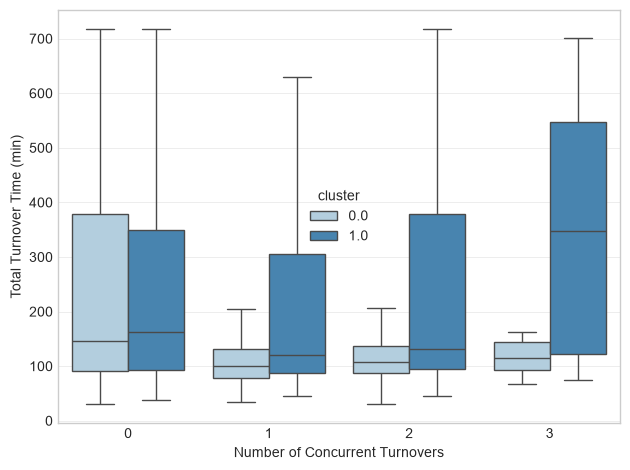

In [162]:
df_box = df_clean[df_clean['cluster_strain'].notna()].copy()

df_box['cluster_strain'] = df_box['cluster_strain'].astype(int)

df_turnover_box = df_box[df_box['turnover_min'] < 720].copy()

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.figure()

sns.boxplot(
    data=df_turnover_box,
    x='cluster_strain',
    y='turnover_min',
    hue='cluster',
    palette='Blues',
    showfliers=False,
)

plt.xlabel('Number of Concurrent Turnovers')
plt.ylabel('Total Turnover Time (min)')

plt.tight_layout()
plt.show()

### Anestesia prep time

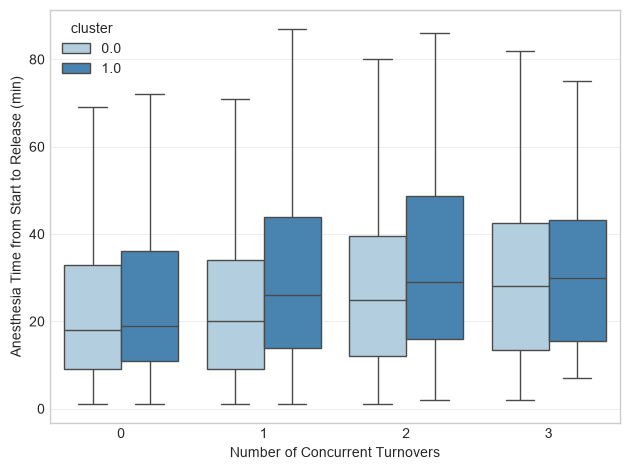

In [163]:
df_prep_box = df_box[df_box['anes_prep_time'] > 0].copy()

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.figure()

sns.boxplot(
    data=df_prep_box,
    x='cluster_strain',
    y='anes_prep_time',
    hue='cluster',
    palette='Blues',
    showfliers=False,
)

plt.xlabel('Number of Concurrent Turnovers')
plt.ylabel('Anesthesia Time from Start to Release (min)')

plt.tight_layout()
plt.show()

### Wakeup time

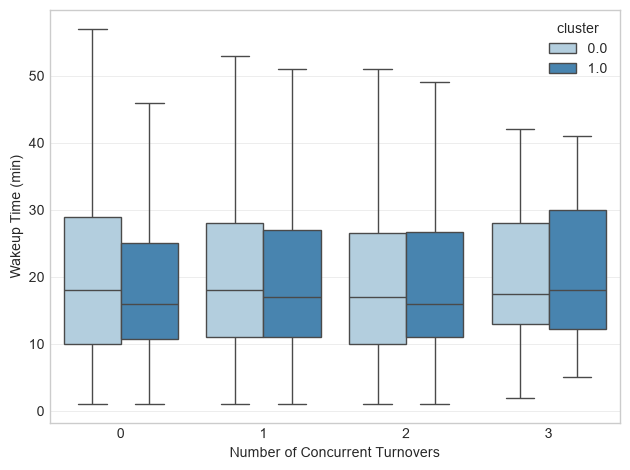

In [164]:
df_wakeup_box = df_box[df_box['wakeup_time'] > 0].copy()

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.figure()

sns.boxplot(
    data=df_wakeup_box,
    x='cluster_strain',
    y='wakeup_time',
    hue='cluster',
    palette='Blues',
    showfliers=False,
)

plt.xlabel('Number of Concurrent Turnovers')
plt.ylabel('Wakeup Time (min)')

plt.tight_layout()
plt.show()

### Dark time

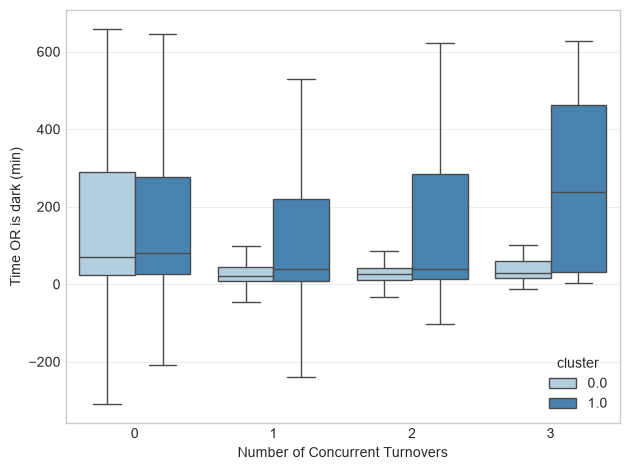

In [165]:
df_empty_box = df_box[df_box['empty_min'] < 720].copy()

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('seaborn-whitegrid')

plt.figure()

sns.boxplot(
    data=df_empty_box,
    x='cluster_strain',
    y='empty_min',
    hue='cluster',
    palette='Blues',
    showfliers=False,
)

plt.xlabel('Number of Concurrent Turnovers')
plt.ylabel('Time OR is dark (min)')

plt.tight_layout()
plt.show()

## Models
### Turnover

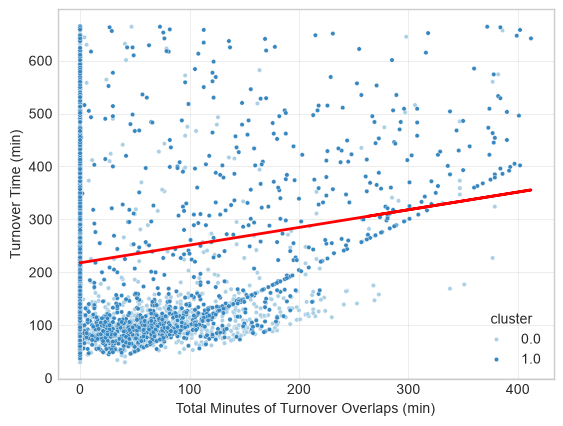

In [166]:
df_scatter = df_clean[df_clean['cluster_strain_min'].notna()].copy()

x_cap = df_scatter['cluster_strain_min'].quantile(0.98)
df_scatter = df_scatter[df_scatter['cluster_strain_min'] <= x_cap]

df_scatter_turnover = df_scatter[df_scatter['turnover_min'] > 0].copy()
y_cap = df_scatter_turnover['turnover_min'].quantile(0.98)
df_scatter_turnover = df_scatter_turnover[df_scatter_turnover['turnover_min'] <= y_cap]

turnover_intercept = turnover_c_result.params['Intercept']
turnover_slope = turnover_c_result.params['cluster_strain_min']

x_vals = df_scatter_turnover['cluster_strain_min'].unique()
y_vals = turnover_intercept + turnover_slope * x_vals

plt.figure()

sns.scatterplot(
    data=df_scatter_turnover,
    x='cluster_strain_min',
    y='turnover_min',
    hue='cluster',
    palette='Blues',
    s=10,
)

plt.plot(x_vals, y_vals, color='red', linewidth=2)

plt.xlabel('Total Minutes of Turnover Overlaps (min)')
plt.ylabel("Turnover Time (min)")

plt.show()

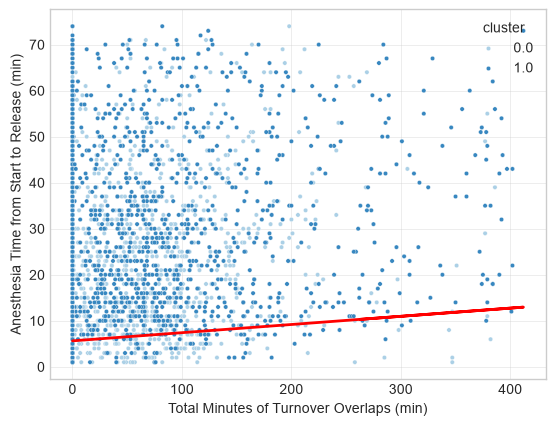

In [167]:
prep_intercept = prep_result.params['Intercept']
prep_slope = prep_result.params['cluster_strain_min']

df_scatter_prep = df_scatter[df_scatter['anes_prep_time'] > 0].copy()
y_cap = df_scatter_prep['anes_prep_time'].quantile(0.98)
df_scatter_prep = df_scatter_prep[df_scatter_prep['anes_prep_time'] < y_cap]

x_vals = df_scatter_prep['cluster_strain_min'].unique()
y_vals = prep_intercept + prep_slope * x_vals

plt.figure()

sns.scatterplot(
    data=df_scatter_prep,
    x='cluster_strain_min',
    y='anes_prep_time',
    hue='cluster',
    palette='Blues',
    s=10,
)

plt.plot(x_vals, y_vals, color='red', linewidth=2)
plt.xlabel('Total Minutes of Turnover Overlaps (min)')
plt.ylabel("Anesthesia Time from Start to Release (min)")

plt.show()

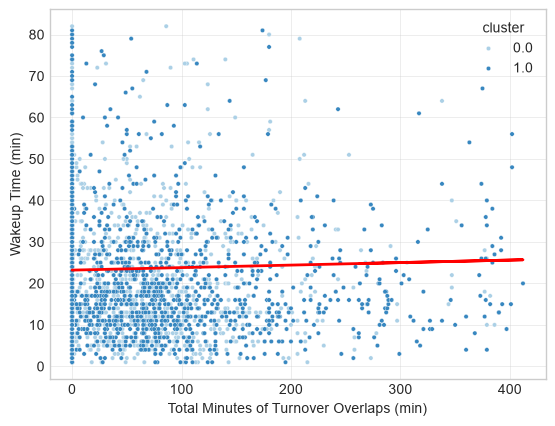

In [168]:
wakeup_intercept = wakeup_result.params['Intercept']
wakeup_slope = wakeup_result.params['cluster_strain_min']

df_scatter_wakeup = df_scatter[df_scatter['wakeup_time'] > 0].copy()
y_cap = df_scatter_wakeup['wakeup_time'].quantile(0.98)
df_scatter_wakeup = df_scatter_wakeup[df_scatter_wakeup['wakeup_time'] < y_cap]

x_vals = df_scatter_wakeup['cluster_strain_min'].unique()
y_vals = wakeup_intercept + wakeup_slope * x_vals

plt.figure()

sns.scatterplot(
    data=df_scatter_wakeup,
    x='cluster_strain_min',
    y='wakeup_time',
    hue='cluster',
    palette='Blues',
    s=10,
)

plt.plot(x_vals, y_vals, color='red', linewidth=2)
plt.xlabel('Total Minutes of Turnover Overlaps (min)')
plt.ylabel("Wakeup Time (min)")

plt.show()

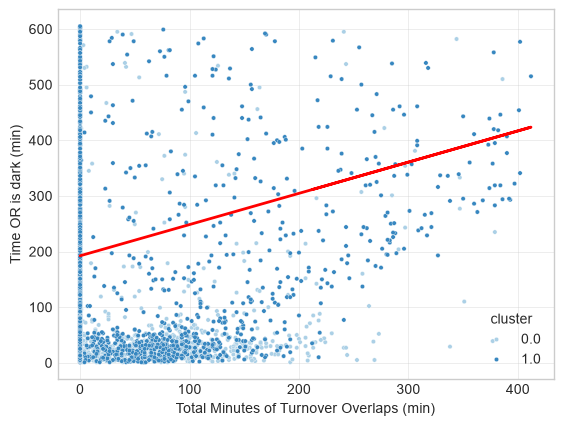

In [169]:
empty_intercept = empty_result.params['Intercept']
empty_slope = empty_result.params['cluster_strain_min']

df_scatter_empty = df_scatter[df_scatter['empty_min'] > 0].copy()
y_cap = df_scatter_empty['empty_min'].quantile(0.98)
df_scatter_empty = df_scatter_empty[df_scatter_empty['empty_min'] < y_cap]

x_vals = df_scatter_empty['cluster_strain_min'].unique()
y_vals = empty_intercept + empty_slope * x_vals

plt.figure()

sns.scatterplot(
    data=df_scatter_empty,
    x='cluster_strain_min',
    y='empty_min',
    hue='cluster',
    palette='Blues',
    s=10,
)

plt.plot(x_vals, y_vals, color='red', linewidth=2)
plt.xlabel('Total Minutes of Turnover Overlaps (min)')
plt.ylabel("Time OR is dark (min)")

plt.show()

# Zeego analysis

In [170]:
df_zeego = df_clean[df_clean['room'].isin(['OP2-08', 'OP2-09'])]

other_types = set()

def parse_zeego_type(text):
    if pd.isna(text):
        return np.nan

    text = str(text).upper()

    if re.search(r'(Z|E)E+G+O\s*\.?\s*(III|3)', text):
        return 'Zeego 3'

    elif re.search(r'(Z|E)E+G+O\s*(II|2)', text):
        return 'Zeego 2'

    elif re.search(r'(Z|E)E+G+O\s*(I|1)\b', text):
        return 'Zeego 1'

    other_types.add(text)
    return np.nan

df_zeego['zeego'] = df_zeego['procedure_type'].apply(parse_zeego_type)
print(df_zeego['zeego'].value_counts(dropna=False))

df_zeego = df_zeego.sort_values(by=['room', 'incision_final'])
df_zeego['zeego_state'] = df_zeego.groupby('room')['zeego'].ffill()
df_zeego['prev_zeego_state'] = df_zeego.groupby('room')['zeego_state'].shift(1)

def check_zeego_reconfig(row):
    curr_state = row['zeego_state']
    prev_state = row['prev_zeego_state']

    if curr_state != prev_state:
        return 1

    return 0

df_zeego['zeego_switch'] = df_zeego.apply(check_zeego_reconfig, axis=1)

zeego
Zeego 1    448
NaN        370
Zeego 2    198
Zeego 3     45
Name: count, dtype: int64


## Raw ANOVA / T-test

In [171]:
switches = df_zeego[df_zeego['zeego_switch'] == 1]['turnover_min'].dropna()
no_switches = df_zeego[df_zeego['zeego_switch'] == 0]['turnover_min'].dropna()

print(f"Average Turnover (NO Switch): {no_switches.mean():.1f} mins")
print(f"Average Turnover (WITH Switch): {switches.mean():.1f} mins")

t_stat, p_val = stats.ttest_ind(switches, no_switches, equal_var=False)
print(f"Raw Difference: {switches.mean() - no_switches.mean():.1f} mins (P-value: {p_val:.4f})\n")

Average Turnover (NO Switch): 172.4 mins
Average Turnover (WITH Switch): 193.1 mins
Raw Difference: 20.8 mins (P-value: 0.0630)



## model

In [180]:
cols_needed = ['turnover_min', 'cluster_strain_min', 'priority', 'zeego_switch', 'anes_min', 'suture_final']
df_zeego_clean = df_zeego[cols_needed].dropna()

x_cap = df_zeego_clean['cluster_strain_min'].quantile(0.98)
df_zeego_clean = df_zeego_clean[df_zeego_clean['cluster_strain_min'] <= x_cap]
df_zeego_clean['log_turnover'] = np.log(df_zeego_clean['turnover_min'])

zeego_model = smf.ols(
    formula="log_turnover ~ cluster_strain_min + C(priority) + anes_min + C(zeego_switch)",
    data=df_zeego_clean
)

zeego_result = zeego_model.fit(cov_type='HC3')
print("--- Impact of Zeego reconfiguration on Turnover Time ---")
print(zeego_result.summary())

--- Impact of Zeego reconfiguration on Turnover Time ---
                            OLS Regression Results                            
Dep. Variable:           log_turnover   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     20.35
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           1.79e-28
Time:                        18:05:25   Log-Likelihood:                -816.27
No. Observations:                 914   AIC:                             1651.
Df Residuals:                     905   BIC:                             1694.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [193]:
df_optimized = df_zeego_clean[df_model_ready['turnover_min'] <= 240].copy()

df_optimized['log_turnover'] = np.log(df_optimized['turnover_min'])

optimized_model = smf.ols(
    formula="turnover_min ~ cluster_strain_min + C(priority) + anes_min + C(zeego_switch)",
    data=df_optimized
)

optimized_result = optimized_model.fit(cov_type='HC3')

print("--- HYPER-OPTIMIZED LOG-LINEAR OLS ---")
print(optimized_result.summary())

--- HYPER-OPTIMIZED LOG-LINEAR OLS ---
                            OLS Regression Results                            
Dep. Variable:           turnover_min   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     17.29
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           9.73e-24
Time:                        19:25:31   Log-Likelihood:                -3747.6
No. Observations:                 757   AIC:                             7513.
Df Residuals:                     748   BIC:                             7555.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

## Graph

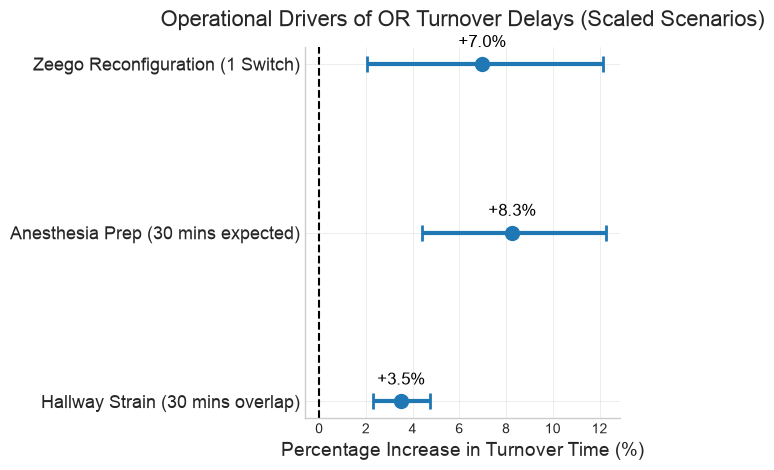

In [192]:
import matplotlib.pyplot as plt
import numpy as np

variables = ['C(zeego_switch)[T.1]', 'anes_min', 'cluster_strain_min']
labels = [
    'Zeego Reconfiguration (1 Switch)',
    'Anesthesia Prep (30 mins expected)',
    'Hallway Strain (30 mins overlap)'
]

multipliers = np.array([1, 30, 30])

coefs = optimized_result.params[variables] * multipliers
cis_lower = optimized_result.conf_int()[0].loc[variables] * multipliers
cis_upper = optimized_result.conf_int()[1].loc[variables] * multipliers

pct_impact = (np.exp(coefs) - 1) * 100
pct_lower = (np.exp(cis_lower) - 1) * 100
pct_upper = (np.exp(cis_upper) - 1) * 100

errors = [pct_impact - pct_lower, pct_upper - pct_impact]

fig, ax = plt.subplots()

ax.errorbar(pct_impact, range(len(variables)), xerr=errors, fmt='o',
            color='#1f77b4', markersize=10, capsize=6, capthick=2, elinewidth=3)

ax.set_yticks(range(len(variables)))
ax.set_yticklabels(labels, fontsize=13, weight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

ax.set_xlabel('Percentage Increase in Turnover Time (%)', fontsize=14, weight='bold')
ax.set_title('Operational Drivers of OR Turnover Delays (Scaled Scenarios)', fontsize=16, weight='bold', pad=15)

for i, val in enumerate(pct_impact):
    ax.text(val, i - 0.1, f"+{val:.1f}%", ha='center', fontsize=12, color='black', weight='bold')

plt.gca().invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()